In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score,roc_auc_score,precision_score,recall_score

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\SVM\product_sales_dataset_final.csv")
df

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,08-15-23,William Jackson,Boston,Massachusetts,East,United States,Home & Furniture,Storage,Storage Rack,4,254.42,1017.68,334.72
199996,199997,10-17-23,Sharon Ferrell,Bismarck,North Dakota,Centre,United States,Accessories,Small Electronics,Charging Cable,1,237.04,237.04,46.53
199997,199998,12-03-23,Katie Rivera,Santa Fe,New Mexico,West,United States,Accessories,Wearable Accessories,Sunglasses,2,106.83,213.66,102.57
199998,199999,12-08-23,Lisa Sullivan,New York City,New York,East,United States,Clothing & Apparel,Women's Wear,Zara Blouse,2,353.01,706.02,288.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  object 
 2   Customer_Name  200000 non-null  object 
 3   City           200000 non-null  object 
 4   State          200000 non-null  object 
 5   Region         200000 non-null  object 
 6   Country        200000 non-null  object 
 7   Category       200000 non-null  object 
 8   Sub_Category   200000 non-null  object 
 9   Product_Name   200000 non-null  object 
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 21.4+ MB


In [4]:
df.isnull().sum()
df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower()

In [5]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

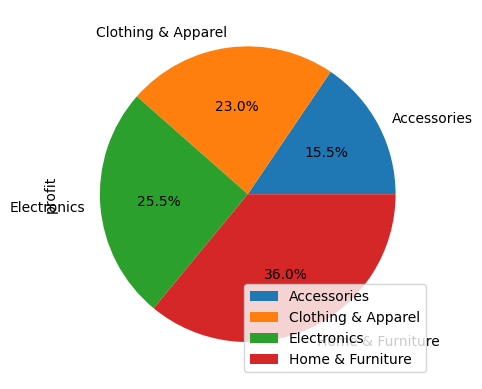

In [6]:
# Plot the distribution of average profit across product categories
df.groupby('category')['profit'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

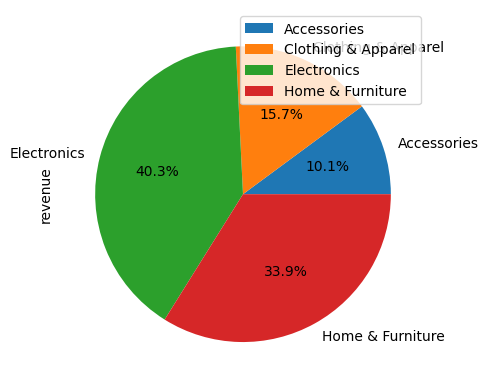

In [7]:
# Plot the distribution of average revenue across product categories
df.groupby('category')['revenue'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

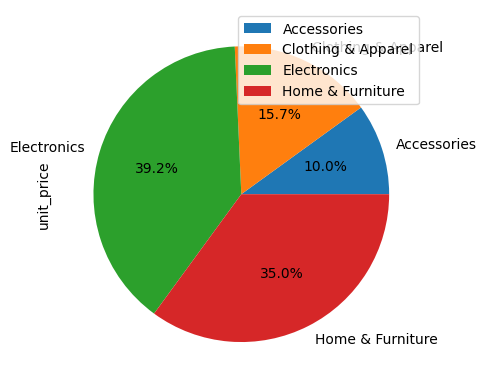

In [8]:
# Plot the distribution of average unit price across product categories
df.groupby('category')['unit_price'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

In [9]:
# Calculate and print the variance for all numerical features to understand discriminative power
for i in df.select_dtypes(include='number').columns:
  print(i,np.var(df[i]))

order_id 3333333333.25
quantity 1.2111740000000004
unit_price 76656.74350116927
revenue 551261.2549821931
profit 24239.12451757594


In [10]:
# Convert 'order_date' column to datetime objects
df['order_date']=pd.to_datetime(df['order_date'])

C:\Users\HP\AppData\Local\Temp\ipykernel_6208\2962252389.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [11]:
# Extract the month from the 'order_date' and create a new 'order_month' column
df['order_month']=df['order_date'].dt.month

In [12]:
# Calculate 'cost_price' based on revenue, profit, and quantity
df['cost_price']=(df['revenue']-df['profit'])/df['quantity']

<Axes: xlabel='order_month', ylabel='profit'>

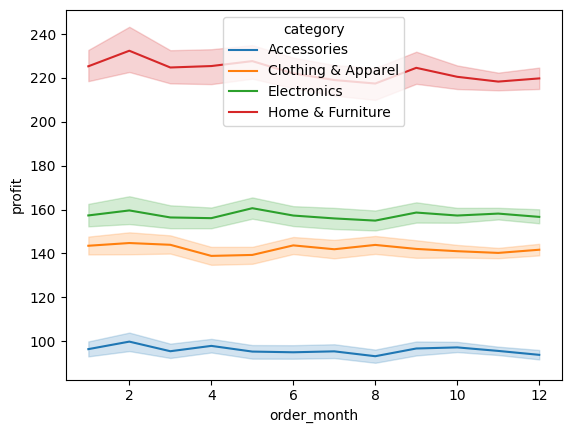

In [13]:
import seaborn as sns
# Plot profit trends over months for each category
sns.lineplot(data=df,x='order_month',y='profit', hue='category')

<Axes: xlabel='order_month', ylabel='revenue'>

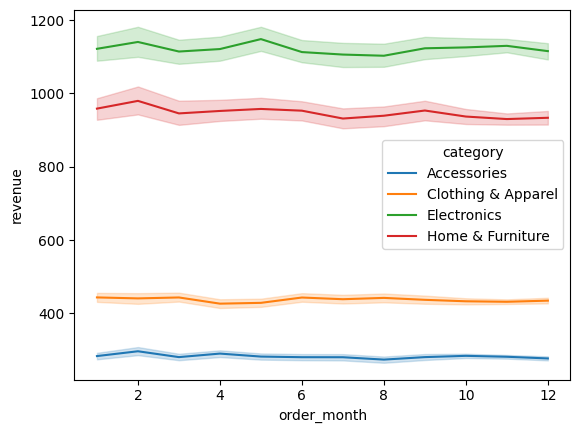

In [14]:
# Plot revenue trends over months for each category
sns.lineplot(data=df,x='order_month',y='revenue', hue='category')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       200000 non-null  int64         
 1   order_date     200000 non-null  datetime64[ns]
 2   customer_name  200000 non-null  object        
 3   city           200000 non-null  object        
 4   state          200000 non-null  object        
 5   region         200000 non-null  object        
 6   country        200000 non-null  object        
 7   category       200000 non-null  object        
 8   sub_category   200000 non-null  object        
 9   product_name   200000 non-null  object        
 10  quantity       200000 non-null  int64         
 11  unit_price     200000 non-null  float64       
 12  revenue        200000 non-null  float64       
 13  profit         200000 non-null  float64       
 14  order_month    200000 non-null  int32         
 15  

In [16]:
df.isnull().sum()

order_id         0
order_date       0
customer_name    0
city             0
state            0
region           0
country          0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
revenue          0
profit           0
order_month      0
cost_price       0
dtype: int64

<Axes: ylabel='profit'>

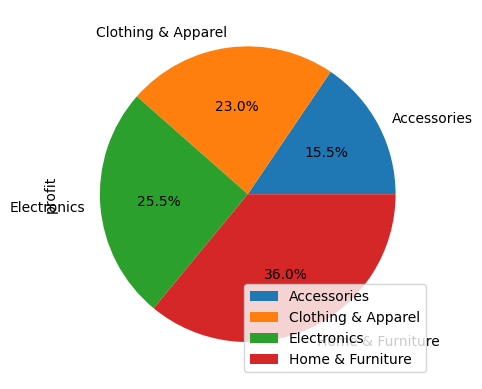

In [17]:
# Plot the distribution of average profit across product categories
df.groupby('category')['profit'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')

<Axes: ylabel='unit_price'>

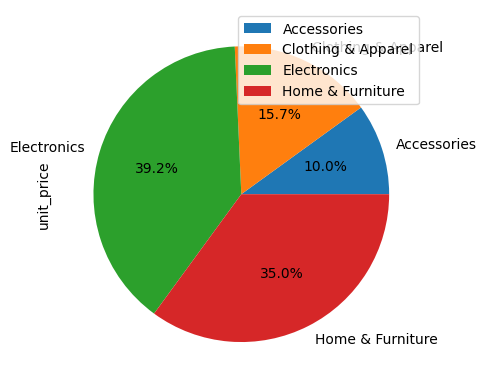

In [18]:
df.groupby('category')['unit_price'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')

What insights from EDA indicate that category prediction is feasible?

In [19]:

print("Category Distribution (sampled data):\n", df["category"].value_counts())

# Quantify Feature Differences by Category
# Calculate and display the mean of key numerical features for each product category
numerical_features = ['profit', 'revenue', 'unit_price', 'quantity', 'cost_price']
print("\nMean of numerical features by category:")
print(df.groupby('category')[numerical_features].mean())

Category Distribution (sampled data):
 category
Clothing & Apparel    62298
Electronics           51230
Home & Furniture      50564
Accessories           35908
Name: count, dtype: int64

Mean of numerical features by category:
                        profit      revenue  unit_price  quantity  cost_price
category                                                                     
Accessories          95.745970   281.643495  149.205044  1.887017   98.391859
Clothing & Apparel  141.687558   435.557567  235.184555  1.854361  158.792694
Electronics         157.429512  1122.110054  586.883379  1.895667  504.554934
Home & Furniture    221.869244   942.853156  524.007303  1.787893  400.924052


In [20]:
print(df['category'].value_counts())

category
Clothing & Apparel    62298
Electronics           51230
Home & Furniture      50564
Accessories           35908
Name: count, dtype: int64


In [21]:
numerical_features = ['profit', 'revenue', 'unit_price', 'quantity', 'cost_price']
print("\nMean of numerical features by category:")
print(df.groupby('category')[numerical_features].mean())


Mean of numerical features by category:
                        profit      revenue  unit_price  quantity  cost_price
category                                                                     
Accessories          95.745970   281.643495  149.205044  1.887017   98.391859
Clothing & Apparel  141.687558   435.557567  235.184555  1.854361  158.792694
Electronics         157.429512  1122.110054  586.883379  1.895667  504.554934
Home & Furniture    221.869244   942.853156  524.007303  1.787893  400.924052


In [22]:
df.head(5)

,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit,order_month,cost_price
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,8,127.180000
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,12,50.027500
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,1,42.720000
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,11,132.513333
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,9,174.170000


In [23]:
df=df.drop_duplicates().dropna()
df=df.sample(50000)

In [24]:
label_encoder=LabelEncoder()
df['category_encoder']=label_encoder.fit_transform(df['category'])


In [25]:
x=df.select_dtypes(include=[np.number]).drop("category_encoder",axis=1)
y=df['category_encoder']

In [26]:
# 3. EXPLORATORY DATA ANALYSIS

print(df.shape)
print(df['category'].value_counts())
print(x.describe())

(50000, 17)
category
Clothing & Apparel    15599
Electronics           12874
Home & Furniture      12640
Accessories            8887
Name: count, dtype: int64
            order_id      quantity    unit_price       revenue        profit  \
count   50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean   100007.073740      1.858820    382.507964    710.949692    157.533537   
std     57778.303367      1.107607    276.409597    737.335979    154.743204   
min         1.000000      1.000000     18.440000     19.470000      4.680000   
25%     49764.750000      1.000000    162.357500    230.397500     59.070000   
50%     99839.000000      1.000000    304.580000    466.575000    109.340000   
75%    150305.250000      2.000000    559.610000    883.770000    199.530000   
max    199998.000000      9.000000   1380.840000   8586.410000   1989.920000   

        order_month    cost_price  
count  50000.000000  50000.000000  
mean       7.904600    297.567493  
std        3

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)


# 5. SVM MODEL

In [28]:
svm=SVC(kernel='rbf',probability=True,random_state=42)
svm.fit(x_train,y_train)



,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
y_pred=svm.predict(x_test)
y_prob=svm.predict_proba(x_test)


# 6. MODEL EVALUATION

In [30]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average='weighted')
recall=recall_score(y_test,y_pred,average='weighted')
roc_auc=roc_auc_score(y_test,y_prob,multi_class='ovr')

print("Model performance")
print(f"Accuracy : {accuracy:.2%}")
print(f"precision :{precision:.2%}")
print(f"Recall:{recall:.2%}")
print(f"ROC AUC:{roc_auc:.2%}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n",
    classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Model performance
Accuracy : 65.70%
precision :67.92%
Recall:65.70%
ROC AUC:88.74%

Confusion Matrix:
 [[1504  700   12    6]
 [1212 2536    0  152]
 [  84   56 2861  217]
 [ 316  674  859 1311]]

Classification Report:
                     precision    recall  f1-score   support

       Accessories       0.48      0.68      0.56      2222
Clothing & Apparel       0.64      0.65      0.64      3900
       Electronics       0.77      0.89      0.82      3218
  Home & Furniture       0.78      0.41      0.54      3160

          accuracy                           0.66     12500
         macro avg       0.67      0.66      0.64     12500
      weighted avg       0.68      0.66      0.65     12500



 7. BUSINESS RESULTS

In [31]:
print(f"Manual categorization reduction ≈ {accuracy*100:.2f}%")

feature_importance = pd.Series(x.var(), index=x.columns).sort_values(ascending=False)
print("\nTop Feature Contributors:\n", feature_importance.head())

category_accuracy = classification_report(
    y_test, y_pred, target_names=label_encoder.classes_, output_dict=True
)

print("\nCategory-wise Accuracy:")
for cat in label_encoder.classes_:
    print(f"{cat}: {category_accuracy[cat]['recall']:.2%}")

Manual categorization reduction ≈ 65.70%

Top Feature Contributors:
 order_id      3.338332e+09
revenue       5.436643e+05
unit_price    7.640227e+04
cost_price    5.555279e+04
profit        2.394546e+04
dtype: float64

Category-wise Accuracy:
Accessories: 67.69%
Clothing & Apparel: 65.03%
Electronics: 88.91%
Home & Furniture: 41.49%


Model Performance Summary and Business Insights
Model Performance:

Accuracy:
The model achieved an overall accuracy of 65.70%, meaning it correctly classified product categories in nearly two-thirds of the cases, demonstrating reasonable automation capability.

Precision (Weighted):
With a weighted precision of 67.92%, when the model predicts a category, it is correct approximately 68% of the time, even after accounting for class imbalance.

Recall (Weighted):
The model recorded a recall of 65.70%, indicating it successfully identifies around 66% of all actual product instances across categories.

ROC AUC (OvR):
A strong ROC AUC score of 88.74% shows that the model has good class separability, confirming its ability to distinguish between multiple product categories despite moderate accuracy.

Confusion Matrix:
The confusion matrix highlights category-wise prediction behavior. Electronics shows a high number of correct predictions (2861) with comparatively fewer misclassifications. Home & Furniture exhibits significant misclassification, particularly with Accessories and Clothing & Apparel, indicating overlapping transactional patterns.

Classification Report:

Electronics achieves the highest recall (89%), demonstrating strong identification of electronic products due to clear pricing and revenue patterns.

Clothing & Apparel shows moderate precision (64%) and recall (65%), reflecting partial overlap with other categories.

Accessories records higher recall (68%) but lower precision (48%), suggesting frequent confusion with neighboring categories.

Home & Furniture has the lowest recall (41%), indicating the model struggles to capture all instances of this category because of similarity in sales behavior with Accessories and Electronics.

Business Insight:

With an overall accuracy of 65.7%, the model can automate approximately two-thirds of product categorization, potentially reducing manual classification effort by ~66%. Performance is strongest for Electronics, while Accessories and Home & Furniture require further feature engineering or model tuning to improve separability.